In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# set_theme: 테마 지정
sns.set_theme(style="whitegrid")

# 폰트 깨짐 방지
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

---
## **실습 1 - C-MAPSS 데이터 열고 구조 확인**
`샘플을 직접 열어 크기와 열 구성을 파악`

In [3]:
# pandas를 불러와 샘플 파일을 데이터프레임으로 열기
df_1 = pd.read_csv("..\\Data\\20_cmapss_fd001_sample.csv")

# 크기 속성으로 행, 열 개수를 확인
print("shape:", df_1.shape)

# 열 이름 속성으로 컬럼을 확인
print("columns:", list(df_1.columns))

# 앞부분을 미리 보며 값의 모양을 눈으로 익히기
print()
print(df_1.head())

# 컬럼별 타입과 채워진 개수까지 확인
print()
df_1.info()

# [확인]
# 1116행 26열 - 엔진번호(unit_nr), 작동회차(time_cycles),
# 운용설정 3개(setting_1~3), 센서 21개(s_1~s_21)로 구성

shape: (1116, 26)
columns: ['unit_nr', 'time_cycles', 'setting_1', 'setting_2', 'setting_3', 's_1', 's_2', 's_3', 's_4', 's_5', 's_6', 's_7', 's_8', 's_9', 's_10', 's_11', 's_12', 's_13', 's_14', 's_15', 's_16', 's_17', 's_18', 's_19', 's_20', 's_21']

   unit_nr  time_cycles  setting_1  setting_2  setting_3     s_1     s_2  \
0        1            1     0.0010    -0.0000      100.0  518.67  641.17   
1        1            2     0.0006    -0.0003      100.0  518.67  640.66   
2        1            3     0.0016    -0.0004      100.0  518.67  641.08   
3        1            4    -0.0008    -0.0002      100.0  518.67  641.18   
4        1            5     0.0007    -0.0002      100.0  518.67  641.13   

       s_3      s_4    s_5  ...    s_12     s_13     s_14   s_15  s_16  s_17  \
0  1589.63  1399.16  14.62  ...  520.73  2387.98  8132.98  8.344  0.03   391   
1  1589.52  1399.28  14.62  ...  521.11  2387.97  8126.66  8.385  0.03   394   
2  1579.31  1394.97  14.62  ...  520.15  2387.97  

---
## **실습 2 - 엔진 단위와 작동 길이 파악**
`여러 엔진이 섞인 구조와 엔진별 작동 길이를 확인`

In [11]:
df_2 = pd.read_csv("..\\Data\\20_cmapss_fd001_sample.csv")

# 엔진번호의 고유값 개수로 엔진이 몇 대인지 세기
# nunique(): 컬럼 안에서 중복을 뺀 고유값의 개수
print("엔진 대수:", df_2["unit_nr"].nunique())

# 엔진번호별 행 수를 세어 각 엔진의 작동 회차 길이를 구하기
# 번호 순으로 정렬해 엔진마다 길이가 다름을 확인
print()
print("[엔진별 작동 회차 수]")
길이_2 = df_2["unit_nr"].value_counts().sort_index()
print(길이_2)

# 가장 짧은 엔진과 가장 긴 엔진을 뽑아서 차이 확인
print()
print("가장 짧은 엔진:", 길이_2.idxmin(), "번 /", 길이_2.min(), "회차")
print("가장 긴 엔진  :", 길이_2.idxmax(), "번 /", 길이_2.max(), "회차")
print("전체 합계     :", 길이_2.sum(), "행 (df 전체 행 수와 같아야 함)")

엔진 대수: 5

[엔진별 작동 회차 수]
unit_nr
1    192
2    287
3    179
4    189
5    269
Name: count, dtype: int64

가장 짧은 엔진: 3 번 / 179 회차
가장 긴 엔진  : 2 번 / 287 회차
전체 합계     : 1116 행 (df 전체 행 수와 같아야 함)


---
## **실습 3 - 요약 통계로 센서 범위 읽기**
`평균, 표준편차, 최소, 최대로 센서 범위를 수치로 파악`

In [5]:
df_3 = pd.read_csv("..\\Data\\20_cmapss_fd001_sample.csv")

# 2번 엔진을 골라 세 센서의 요약 통계를 한 번에 보기
engine_3 = df_3[df_3["unit_nr"] == 2]
print("2번 엔진 행 수:", len(engine_3))
print()
print(engine_3[["s_2", "s_11", "s_12"]].describe().round(2))

# 평균으로 대략 크기를, 표준편차로 변동 정도를 읽기
# 최소, 최대로 각 센서의 값 범위가 서로 다름을 확인
print()
print("[센서별 크기와 폭 비교]")
for sensor in ["s_2", "s_11", "s_12"]:
    s = engine_3[sensor]
    print(f"{sensor:5} 평균 {s.mean():8.2f} | 표준편차 {s.std():5.2f} | 범위 {s.min():.2f} ~ {s.max():.2f} (폭 {s.max()-s.min():.2f})")

# [확인]
# 평균이 641.8 / 47.7 / 517.4로 크기가 제각각이라 같은 축에 그리면 비교가 안 된다
# 표준편차도 0.49 / 0.32 / 2.15로 달라서, 어떤 센서가 더 많이 흔들리는지는
# 평균 대비 비율로 봐야 공평하다

2번 엔진 행 수: 287

          s_2    s_11    s_12
count  287.00  287.00  287.00
mean   641.75   47.69  517.43
std      0.49    0.32    2.15
min    640.46   46.97  512.86
25%    641.39   47.42  515.66
50%    641.70   47.68  517.23
75%    642.14   47.94  519.16
max    642.87   48.44  521.96

[센서별 크기와 폭 비교]
s_2   평균   641.75 | 표준편차  0.49 | 범위 640.46 ~ 642.87 (폭 2.41)
s_11  평균    47.69 | 표준편차  0.32 | 범위 46.97 ~ 48.44 (폭 1.47)
s_12  평균   517.43 | 표준편차  2.15 | 범위 512.86 ~ 521.96 (폭 9.10)


---
## **실습 4 - 변하는 센서 선별과 결측 확인**
`거의 안 변하는 센서를 빼고 쓸 센서를 직접 고르기`

In [6]:
df_4 = pd.read_csv("..\\Data\\20_cmapss_fd001_sample.csv")

# 여러 센서의 흔들림 폭을 비교해 0에 가까운 것은 제외 대상으로 표시
sensors = ["s_1", "s_6", "s_7", "s_11", "s_12"]

for sensor in sensors:
    print(sensor, round(df_4[sensor].std(), 3))

# 센서를 하나씩 손으로 적는 대신 전체를 훑어서 자동으로 골라내기
print()
print("[전체 컬럼 표준편차 스캔]")
std_4 = df_4.std(numeric_only=True).round(4)

제외_4 = std_4[std_4 == 0].index.tolist()
사용_4 = [c for c in std_4.index if c not in 제외_4 and c not in ["unit_nr", "time_cycles"]]

print("제외 대상 (값이 늘 같음):", 제외_4)
print("분석 대상 (뚜렷이 변함):", 사용_4)
print(f"-> 센서 21개 중 {len(제외_4)}개가 상수라 실제로 쓸 수 있는 건 {len(사용_4)}개")

# 결측 합계를 세어 빈 값이 없는지 확인
print()
print("결측 합계: ", df_4.isna().sum().sum())

# [확인]
# s_1, s_6은 표준편차가 0.0 -> 처음부터 끝까지 같은 값이라 분석에 아무 정보도 못 준다
# 이런 상수 컬럼은 그래프를 그려도 직선만 나오고 상관계수는 NaN이 된다

s_1 0.0
s_6 0.0
s_7 2.367
s_11 0.314
s_12 2.119

[전체 컬럼 표준편차 스캔]
제외 대상 (값이 늘 같음): ['setting_3', 's_1', 's_5', 's_6', 's_10', 's_16', 's_18', 's_19']
분석 대상 (뚜렷이 변함): ['setting_1', 'setting_2', 's_2', 's_3', 's_4', 's_7', 's_8', 's_9', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21']
-> 센서 21개 중 8개가 상수라 실제로 쓸 수 있는 건 16개

결측 합계:  0


---
## **실습 5 - 엔진 하나 골라 첫, 끝 추세 읽기**
`한 엔진을 회차 순으로 정렬해 첫, 끝 값으로 방향 판정`

In [7]:
df_5 = pd.read_csv("..\\Data\\20_cmapss_fd001_sample.csv")

# 2번 엔진만 골라 작동 회차 순으로 정렬
# 시계열은 순서가 생명이라 그리기 전에 반드시 정렬부터 한다
engine_5 = df_5[df_5["unit_nr"] == 2].sort_values("time_cycles")

# 상승 센서와 하강 센서의 첫 회차 값과 마지막 값을 꺼내기
print(engine_5[["time_cycles", "s_11", "s_7"]].head(1))
print(engine_5[["time_cycles", "s_11", "s_7"]].tail(1))

# 첫 값과 끝 값을 비교해 상승인지 하강인지 판정
# iloc[0]은 첫 행, iloc[-1]은 마지막 행
print()
for sensor in ["s_11", "s_7", "s_12", "s_20"]:
    start = engine_5[sensor].iloc[0]
    end = engine_5[sensor].iloc[-1]
    방향 = "상승" if end > start else "하강"
    print(f"{sensor:5} {start:>8.2f} -> {end:>8.2f}  ({방향}, 변화량 {end - start:+.2f})")

# 첫값과 끝값만 보면 우연일 수 있으니 회차와의 상관계수로 한 번 더 확인
print()
print("[time_cycles와의 상관계수 - 부호가 곧 추세 방향]")
for sensor in ["s_11", "s_7", "s_12", "s_20", "s_14"]:
    r = engine_5["time_cycles"].corr(engine_5[sensor])
    print(f"{sensor:5} r = {r:+.3f}")

# [확인]
# s_11은 47.30 -> 48.18 상승(r=+0.911), s_7은 553.84 -> 546.17 하강(r=-0.966)
# s_14는 첫끝만 보면 하강처럼 보이지만 r=+0.298로 약해서 노이즈가 큰 센서다
# -> 첫값과 끝값 두 점만으로 추세를 단정하면 안 된다

     time_cycles  s_11     s_7
192            1  47.3  553.84
     time_cycles   s_11     s_7
478          287  48.18  546.17

s_11     47.30 ->    48.18  (상승, 변화량 +0.88)
s_7     553.84 ->   546.17  (하강, 변화량 -7.67)
s_12    520.52 ->   513.55  (하강, 변화량 -6.97)
s_20     38.94 ->    37.94  (하강, 변화량 -1.00)

[time_cycles와의 상관계수 - 부호가 곧 추세 방향]
s_11  r = +0.911
s_7   r = -0.966
s_12  r = -0.968
s_20  r = -0.951
s_14  r = +0.298


---
## **실습 6 - 엔진 센서 시계열 그래프 그리기**
`정렬한 엔진 데이터로 회차 가로축 선 그래프 그리기`

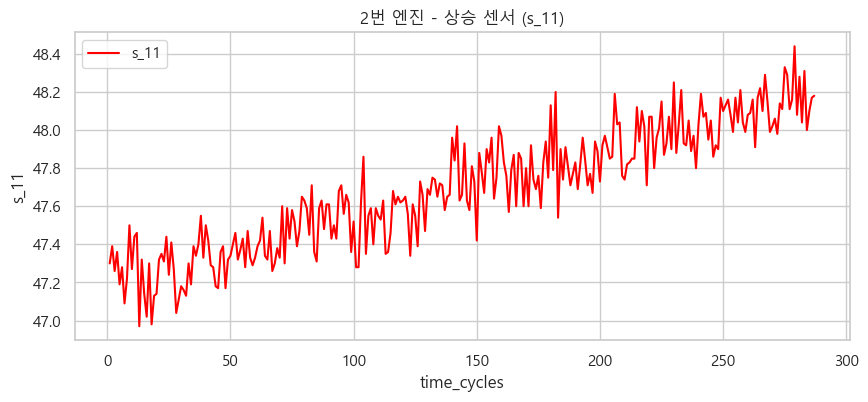

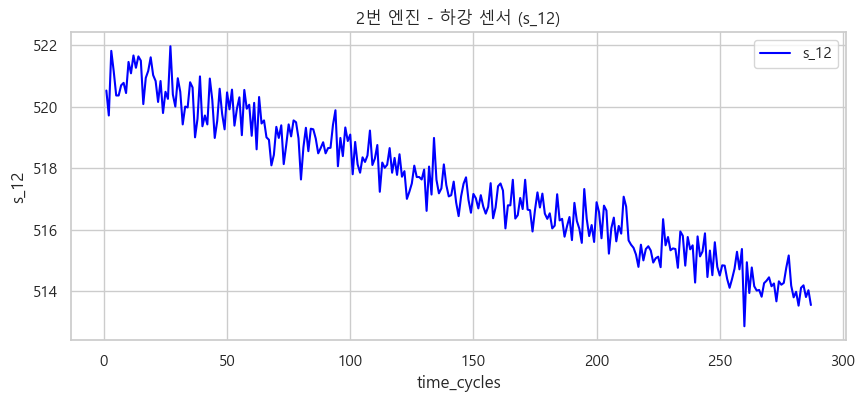

In [8]:
df_6 = pd.read_csv("..\\Data\\20_cmapss_fd001_sample.csv")
engine_6 = df_6[df_6["unit_nr"] == 2].sort_values("time_cycles")

# 상승 센서를 선 그래프로 그리고 제목, 축 이름 붙이기
# X축(시간의 흐름) : time_cycles / Y축(결과) : 센서값
plt.figure(figsize=(10, 4))
plt.title("2번 엔진 - 상승 센서 (s_11)")
plt.plot(engine_6["time_cycles"], engine_6["s_11"], label="s_11", color="red")
plt.xlabel("time_cycles")
plt.ylabel("s_11")
plt.legend()
plt.show()

# 하강 센서도 같은 방식으로 그려 방향을 비교
plt.figure(figsize=(10, 4))
plt.title("2번 엔진 - 하강 센서 (s_12)")
plt.plot(engine_6["time_cycles"], engine_6["s_12"], label="s_12", color="blue")
plt.xlabel("time_cycles")
plt.ylabel("s_12")
plt.legend()
plt.show()

# 두 그래프의 기울기 방향으로 추세를 눈으로 확인
# [확인]
# 점 하나하나는 위아래로 튀지만 전체 흐름은 s_11이 우상향, s_12가 우하향
# 엔진이 마모될수록 센서값이 한쪽으로 밀리는 것이 열화(degradation) 신호

---
## **실습 7 - 여러 센서 비교와 범위 문제**
`여러 센서를 함께 그려 값 범위 차이 문제를 체험`

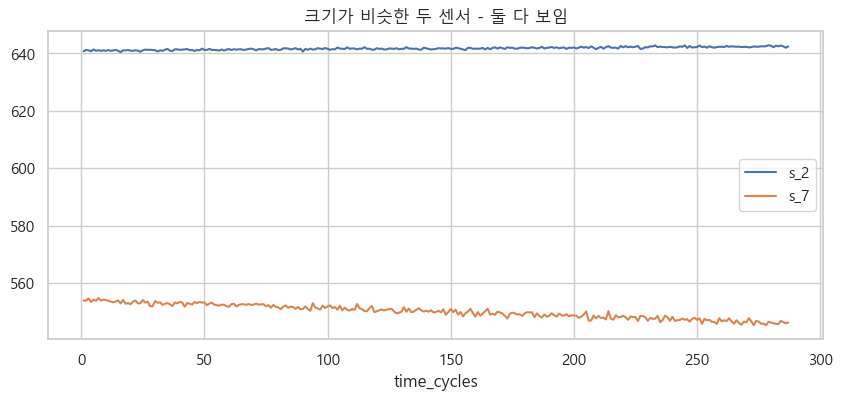

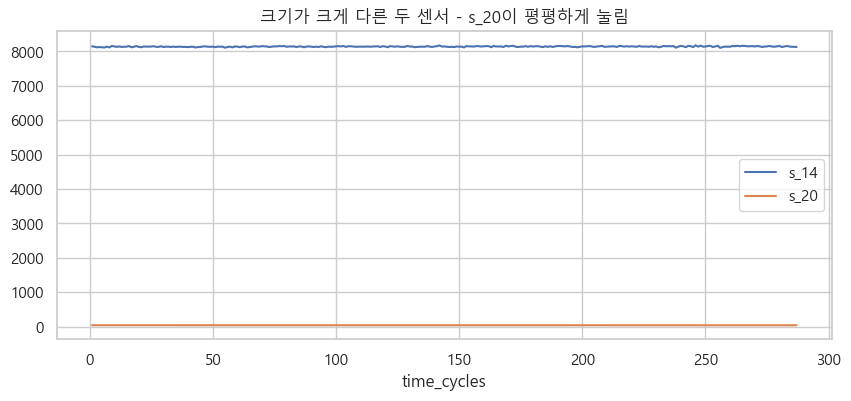

          s_14    s_20
count   287.00  287.00
mean   8138.26   38.45
std      11.93    0.27
min    8099.12   37.88
25%    8130.82   38.23
50%    8138.29   38.45
75%    8145.94   38.66
max    8176.36   39.06

s_14 범위 폭: 77.24
s_20 범위 폭: 1.18


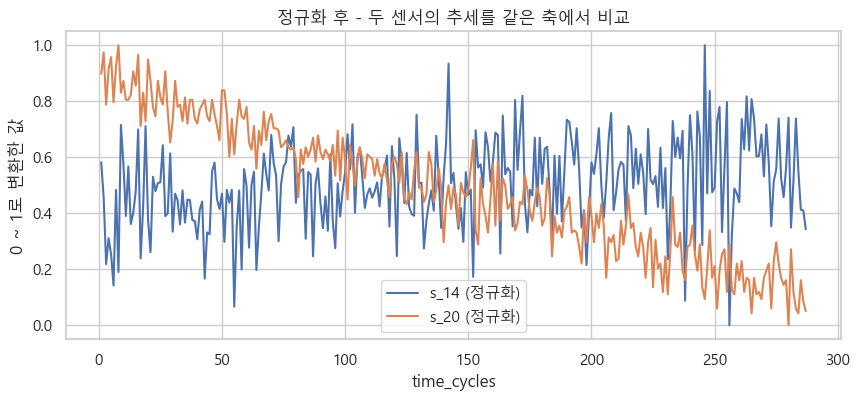

In [9]:
df_7 = pd.read_csv("..\\Data\\20_cmapss_fd001_sample.csv")
engine_7 = df_7[df_7["unit_nr"] == 2].sort_values("time_cycles")

# 크기가 비슷한 두 센서를 함께 그리고 범례를 붙여 비교
# s_2(약 641)와 s_7(약 550)은 자릿수가 같아서 한 축에 놔도 둘 다 보인다
plt.figure(figsize=(10, 4))
plt.title("크기가 비슷한 두 센서 - 둘 다 보임")
plt.plot(engine_7["time_cycles"], engine_7["s_2"], label="s_2")
plt.plot(engine_7["time_cycles"], engine_7["s_7"], label="s_7")
plt.xlabel("time_cycles")
plt.legend()
plt.show()

# 크기가 크게 다른 두 센서를 일부러 겹쳐 그리기
# s_14(약 8100)와 s_20(약 38)은 자릿수가 200배 이상 차이난다
plt.figure(figsize=(10, 4))
plt.title("크기가 크게 다른 두 센서 - s_20이 평평하게 눌림")
plt.plot(engine_7["time_cycles"], engine_7["s_14"], label="s_14")
plt.plot(engine_7["time_cycles"], engine_7["s_20"], label="s_20")
plt.xlabel("time_cycles")
plt.legend()
plt.show()

# 두 센서의 범위를 숫자로 확인해 작은 값이 왜 안 보이는지 이해
print(engine_7[["s_14", "s_20"]].describe().round(2))
print()
print("s_14 범위 폭:", round(engine_7["s_14"].max() - engine_7["s_14"].min(), 2))
print("s_20 범위 폭:", round(engine_7["s_20"].max() - engine_7["s_20"].min(), 2))

# 해결책 1 - 각 센서를 0~1로 정규화해서 같은 축에 올리기
# (값 - 최솟값) / (최댓값 - 최솟값) 이 Min-Max 정규화
plt.figure(figsize=(10, 4))
plt.title("정규화 후 - 두 센서의 추세를 같은 축에서 비교")
for sensor in ["s_14", "s_20"]:
    s = engine_7[sensor]
    정규화 = (s - s.min()) / (s.max() - s.min())
    plt.plot(engine_7["time_cycles"], 정규화, label=f"{sensor} (정규화)")
plt.xlabel("time_cycles")
plt.ylabel("0 ~ 1로 변환한 값")
plt.legend()
plt.show()

# [확인]
# y축이 8100까지 늘어나면서 38짜리 s_20은 바닥에 붙은 직선이 되어 버린다
# 정규화하면 단위가 사라지고 "모양"만 남아서 추세끼리 비교가 가능해진다

---
## **실습 8 - 데이터 구조 미니 리포트**
`오늘 확인한 크기, 엔진, 센서 특성을 짧은 리포트로 정리`

In [ ]:
df_8 = pd.read_csv("..\\Data\\20_cmapss_fd001_sample.csv")

# 전체 크기와 엔진 대수를 한 줄로 출력
print("=" * 60)
print("C-MAPSS FD001 샘플 데이터 구조 리포트")
print("=" * 60)
print(f"전체 크기   : {df_8.shape[0]}행 {df_8.shape[1]}열")
print(f"엔진 대수   : {df_8['unit_nr'].nunique()}대")
print(f"전체 결측   : {df_8.isna().sum().sum()}개")

# 상수 컬럼도 리포트에 포함
# 주의: 부동소수점 때문에 실제로는 1.7e-15 같은 아주 작은 값이 남아
# std == 0 으로 바로 비교하면 s_5, s_6, s_10, s_16이 안 걸린다
# 실습 4와 같은 기준을 쓰려면 round()로 자릿수를 맞춰서 비교해야 한다
std_8 = df_8.std(numeric_only=True).round(4)
상수_8 = std_8[std_8 == 0].index.tolist()
print(f"상수 컬럼   : {len(상수_8)}개 {상수_8}")

# 대상 엔진의 작동 회차 수와 결측 유무를 정리
target = 2
engine_8 = df_8[df_8["unit_nr"] == target].sort_values("time_cycles")
print("-" * 60)
print(f"대상 엔진   : {target}번")
print(f"작동 회차   : {len(engine_8)}회 ({engine_8['time_cycles'].min()} ~ {engine_8['time_cycles'].max()})")
print(f"엔진 결측   : {engine_8.isna().sum().sum()}개")

# 주목 센서 세 개의 첫, 끝 방향을 반복문으로 표처럼 정리
print("-" * 60)
print(f"{'센서':<6}{'첫값':>10}{'끝값':>10}{'변화량':>10}{'방향':>6}{'상관':>8}")
print("-" * 60)
for sensor in ["s_11", "s_7", "s_12", "s_20", "s_14"]:
    start = engine_8[sensor].iloc[0]
    end = engine_8[sensor].iloc[-1]
    r = engine_8["time_cycles"].corr(engine_8[sensor])
    방향 = "상승" if end > start else "하강"
    print(f"{sensor:<6}{start:>10.2f}{end:>10.2f}{end - start:>+10.2f}{방향:>6}{r:>+8.3f}")
print("=" * 60)

C-MAPSS FD001 샘플 데이터 구조 리포트
전체 크기   : 1116행 26열
엔진 대수   : 5대
전체 결측   : 0개
상수 컬럼   : 8개 ['setting_3', 's_1', 's_5', 's_6', 's_10', 's_16', 's_18', 's_19']
------------------------------------------------------------
대상 엔진   : 2번
작동 회차   : 287회 (1 ~ 287)
엔진 결측   : 0개
------------------------------------------------------------
센서            첫값        끝값       변화량    방향      상관
------------------------------------------------------------
s_11       47.30     48.18     +0.88    상승  +0.911
s_7       553.84    546.17     -7.67    하강  -0.966
s_12      520.52    513.55     -6.97    하강  -0.968
s_20       38.94     37.94     -1.00    하강  -0.951
s_14     8144.09   8125.59    -18.50    하강  +0.298
